In [60]:
import matplotlib.pyplot

In [61]:
!pip install opencv-python

In [62]:
import tensorflow as tf
import os

In [ ]:
os.path.join('priya','users')

'priya/users'

In [63]:
gpus=tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu,True)

In [64]:
tf.config.experimental.list_physical_devices('GPU')

[]

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [67]:
os.listdir("/content/drive/MyDrive/dlProject/data")

['sad', 'happy']

In [68]:
import numpy as np
from matplotlib import pyplot as plt

In [130]:
tf.keras.backend.clear_session()

In [131]:
data=tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/dlProject/data',shuffle=True,seed=42) #pipeline building

Found 305 files belonging to 2 classes.


In [132]:
data_iterator=data.as_numpy_iterator() #iterate data

In [133]:
batch=data_iterator.next() #get batch of data

In [135]:
len(batch) # 1 is data other is label

2

In [136]:
#images represented as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [137]:
#tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/data',batch_size=16,image_size=(128,128))

In [138]:
batch[1]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1], dtype=int32)

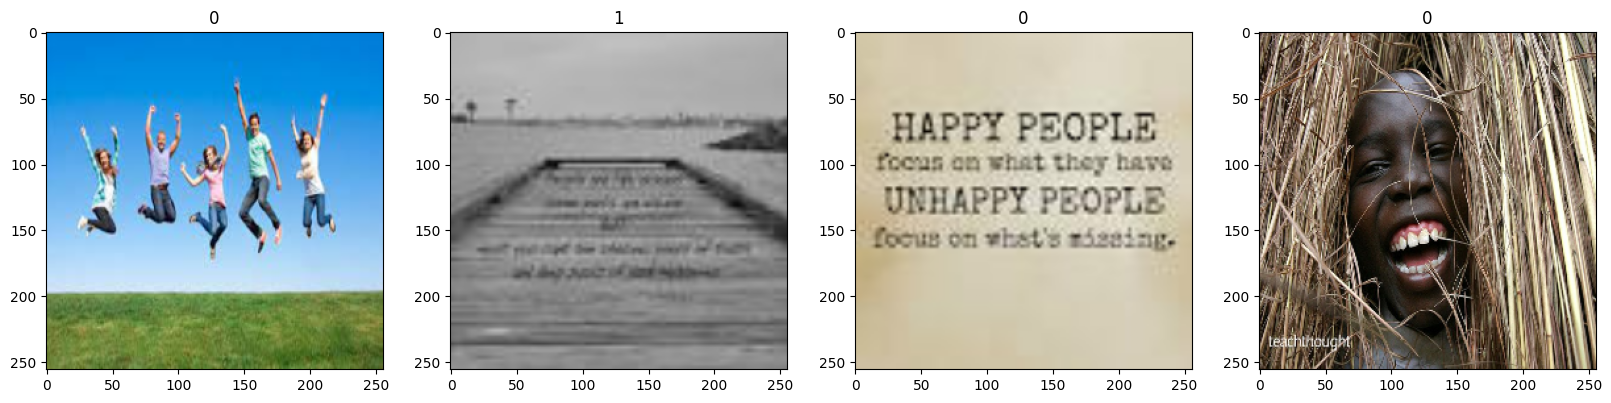

In [139]:
fig,ax=plt.subplots(ncols=4,figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
  ax[idx].imshow(img/255.0)
  ax[idx].title.set_text(batch[1][idx])
  #1-sad
  #0-happy

In [141]:
batch[0].max()

np.float32(255.0)

In [142]:
scaled=batch[0]/255

In [ ]:
scaled.max()

np.float32(1.0)

In [143]:
data=data.map(lambda x,y:(x/255,y))

In [144]:
scaled_iterator=data.as_numpy_iterator()

In [145]:
scaled_iterator.next()[0].min()

np.float32(0.0)

In [146]:
len(data)

10

In [147]:
train_size=int(len(data)*.7)
val_size=int(len(data)*.2)
test_size=int(len(data)*.1)
test_size

1

In [148]:
train=data.take(train_size)
val=data.skip(train_size).take(val_size)
test=data.skip(train_size+val_size).take(test_size)

In [149]:
len(test)

1

In [ ]:
#build model
#single input,single output - sequential model building api
#multiple inputs,multiple outputs - functional model building api

In [150]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout

In [151]:
model=Sequential() #model=Sequential([Conv2D, ....]) can also be done stacking/passing directly

In [152]:
#or adding
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape=(256,256,3))) #16 (3*3) filters to condense or extract info
model.add(MaxPooling2D())
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [153]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [154]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      14,745,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,755,825 (56.29 MB)

 Trainable params: 14,755,825 (56.29 MB)

 Non-trainable params: 0 (0.00 B)

In [155]:
logdir='/content/drive/MyDrive/dlProject/logs'

In [156]:
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [157]:
hist=model.fit(train,epochs=20,validation_data=val,callbacks=[tensorboard_callback])

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.4973 - loss: 1.9866 - val_accuracy: 0.5781 - val_loss: 0.6309
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.6390 - loss: 0.6386 - val_accuracy: 0.7969 - val_loss: 0.5378
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8844 - loss: 0.4870 - val_accuracy: 0.9062 - val_loss: 0.2511
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8728 - loss: 0.2838 - val_accuracy: 0.9219 - val_loss: 0.2373
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9156 - loss: 0.2424 - val_accuracy: 0.9531 - val_loss: 0.1658
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.9490 - loss: 0.1597 - val_accuracy: 0.9688 - val_loss: 0.0873
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.9617 - loss: 0.0959 - val_accuracy: 0.9844 - val_loss: 0.0925
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9800 - loss: 0.0857 - val_accuracy: 0.9844 - val_loss: 0.0424
Epoch 9/

In [158]:
hist.history

{'accuracy': [0.4955357015132904,
  0.6339285969734192,
  0.84375,
  0.8839285969734192,
  0.9107142686843872,
  0.9598214030265808,
  0.9642857313156128,
  0.9866071343421936,
  0.9821428656578064,
  0.9955357313156128,
  1.0,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128,
  0.9955357313156128,
  1.0,
  0.9910714030265808,
  0.9910714030265808,
  0.9955357313156128,
  0.9955357313156128],
 'loss': [1.7666503190994263,
  0.6365893483161926,
  0.4632546305656433,
  0.2885436415672302,
  0.24820788204669952,
  0.13717439770698547,
  0.08953007310628891,
  0.057659633457660675,
  0.050681352615356445,
  0.04059670493006706,
  0.03351462259888649,
  0.0174309890717268,
  0.015435324981808662,
  0.009045802056789398,
  0.0091865761205554,
  0.003328902879729867,
  0.025384286418557167,
  0.021726509556174278,
  0.01453415583819151,
  0.007887871004641056],
 'val_accuracy': [0.578125,
  0.796875,
  0.90625,
  0.921875,
  0.953125,
  0.96875,
  0.984375,
  0.984375,
  1.0,


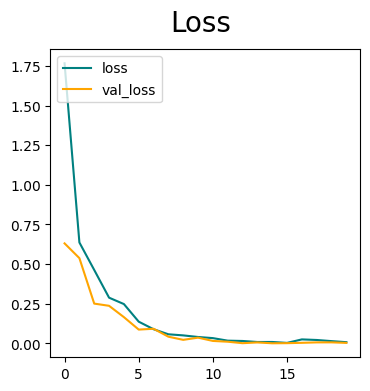

In [159]:
fig=plt.figure(figsize=(4,4))
plt.plot(hist.history['loss'],color='teal',label='loss')
plt.plot(hist.history['val_loss'],color='orange',label='val_loss')
fig.suptitle('Loss',fontsize=20)
plt.legend(loc="upper left")
plt.show()

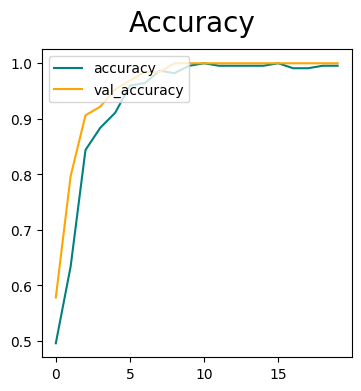

In [160]:
fig=plt.figure(figsize=(4,4))
plt.plot(hist.history['accuracy'],color='teal',label='accuracy')
plt.plot(hist.history['val_accuracy'],color='orange',label='val_accuracy')
fig.suptitle('Accuracy',fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [161]:
from tensorflow.keras.metrics import Precision , Recall, BinaryAccuracy

In [162]:
pre=Precision()
re=Recall()
acc=BinaryAccuracy()

In [163]:
len(test)

1

In [164]:
for batch in test.as_numpy_iterator():
  X,y=batch
  ypred=model.predict(X)
  pre.update_state(y,ypred)
  re.update_state(y,ypred)
  acc.update_state(y,ypred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


In [165]:
pre.result().numpy()

np.float32(1.0)

In [166]:
re.result().numpy()

np.float32(1.0)

In [167]:
acc.result().numpy()

np.float32(1.0)

In [169]:
import cv2#happy0sad1

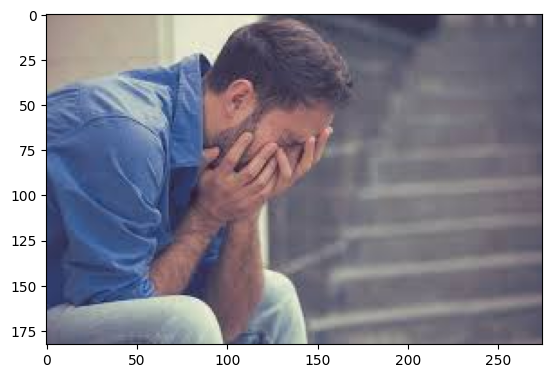

In [186]:
path='/content/drive/MyDrive/dlProject/sadtest.jpg'
img=cv2.imread(path) #opencv reads in bgr rather than rgb
img2=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img2)

In [187]:
resized=tf.image.resize(img2,(256,256))
resized.shape

TensorShape([256, 256, 3])

In [188]:
np.expand_dims(resized,0).shape

(1, 256, 256, 3)

In [189]:
ypred=model.predict(np.expand_dims(resized/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


In [190]:
ypred

array([[0.91608167]], dtype=float32)

In [191]:
if ypred<0.5:
  print("happy")
else:
  print("sad")


sad


In [198]:
model.save(os.path.join('models','happysadmodel.keras'))

In [193]:
new_model=load_model(os.path.join('models','happysadmodel.keras'))

In [194]:
yhatnew=new_model.predict(np.expand_dims(resized/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


In [195]:
if yhatnew<0.5:
  print("happy")
else:
  print("sad")


sad


In [203]:
os.listdir('models')

['happysadmodel.keras']

In [202]:
os.remove('models/happysadmodel.h5')

In [204]:
!cp models/happysadmodel.keras /content/drive/MyDrive/dlProject/models/happysadmodel.keras